# Ajtzibab: Prepare Corpuse

In [505]:
import pandas as pd
import numpy as np
from lxml import etree
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

In [506]:
src_id = "ajtzibab"

# XML to paragraphs

In [507]:
src_file = 'source.v1.tei.xml'
ns = {"tei": "http://www.tei-c.org/ns/1.0", 
      "xml": "http://www.w3.org/TR/html4"}
p_xpath = "//tei:body//tei:p"

In [508]:
tree = etree.parse(src_file)  # Replace with your actual file path
root = tree.getroot()
p_elements = root.xpath(p_xpath, namespaces=ns)

In [509]:
def extract_text_excluding_notes(elem):
    
    # Grab paragraph ID
    p_id_list = elem.xpath('./@xml:id', namespaces=ns)
    if len(p_id_list) == 0:
        p_id = None
    else:
        p_id = float(p_id_list[0].replace('p', ''))
    
    # Serialize the <p> element to string    
    p_str = etree.tostring(elem, encoding="unicode")
    
    # Wrap it in a dummy root element
    wrapped = f"<wrapper xmlns='http://www.tei-c.org/ns/1.0'>{p_str}</wrapper>"
    wrapper_elem = etree.fromstring(wrapped)

    # Remove all <note> elements
    for note in wrapper_elem.xpath(".//tei:note", namespaces=ns):
        note.getparent().remove(note)

    # Get all remaining <p> elements and concatenate their text
    text_parts = []
    for p in wrapper_elem.xpath(".//tei:p", namespaces=ns):
        text_parts.append(''.join(p.itertext()))
    p_text = ' '.join(text_parts)

    # Return id and text
    return (p_id, p_text)



In [510]:
paragraphs = [extract_text_excluding_notes(p) for p in p_elements]
paragraphs[:10]

[(None, 'POPOL WUJ'),
 (None, 'OJER TAQ TZIJ'),
 (None, "XB'AN PA TINAMIT K'ICHE',"),
 (None, "RAMAQ' K'ICHE' WINAQ"),
 (None, '\n        \n      '),
 (None, 'Versión crítica y actualizada'),
 (None, "Ajtz'ib'ab'"),
 (None, "Nab'e"),
 (1.0, "\n      \n      Are' uxe' ojer tzij waral K'iche' ub'i'."),
 (2.0, "\n      \n      Waral xchiqatz'ib'aj wi")]

# paragraphs to DOC

In [511]:
# Convert to dataframe
DOC = pd.DataFrame(paragraphs, columns=['para_num', 'para_str'])
DOC.para_str = DOC.para_str.replace(r"\d+\s*", " ", regex=True)
DOC.para_str = DOC.para_str.str.strip()
DOC.para_num = DOC.para_num.ffill()
DOC.loc[DOC.para_num.isna(), 'para_num'] = 0
DOC.para_num = DOC.para_num.astype(int)
DOC['line_id'] = DOC.groupby('para_num').cumcount() + 1
DOC = DOC.set_index(['para_num','line_id'])
DOC

para_str
para_num line_id                                    
0        1                                 POPOL WUJ
         2                             OJER TAQ TZIJ
         3                 XB'AN PA TINAMIT K'ICHE',
         4                      RAMAQ' K'ICHE' WINAQ
         5                                          
...                                              ...
152      8              rumal maja b'i chi ilb'al re
         9              k'o nab'e ojer kumal ajawab'
         10                           sachinaq chik.
         11       Xere k'u ri mixutzinik chi konojel
         12                 K'iche' Sta. Cruz ub'i'.

[6278 rows x 1 columns]

# DOC to TOKEN

In [512]:
# Convert paragraphs to tokens
TOKEN = DOC.para_str.str.split(expand=True).stack().to_frame('token_str')
TOKEN.index.names = DOC.index.names + ['token_num']

In [513]:
# Create normalized terms from tokens
TOKEN['term_str'] = (
    TOKEN
        .token_str.str.replace(r"\d+", "", regex=True)
        .str.replace('.', '')
        .str.replace(',', '')
        .str.lower()
        .str.strip()
)

# Remove blanks
TOKEN = TOKEN[~TOKEN.term_str.str.match(r'^\s*$')]
TOKEN.head()

token_str term_str
para_num line_id token_num                   
0        1       0             POPOL    popol
                 1               WUJ      wuj
         2       0              OJER     ojer
                 1               TAQ      taq
                 2              TZIJ     tzij

# TOKEN to DTM

In [514]:
DTM = TOKEN.groupby(['para_num', 'term_str']).term_str.count().unstack(fill_value=0)
DTM

term_str,a,a',a'on,ab'aj,ab'ajil,ab'anel,ab'anoj,ab'i',ab'ix,ab'ixik,...,yan,ye'oltux,yitz',yitz'il,yojol,yolkwat,yoq'b'al,yoq'otajinaq,yub'jan,yujuj
para_num,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
149,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# DTM to VOCAB

In [515]:
VOCAB = DTM.sum().to_frame('n')
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['h'] = VOCAB.p * VOCAB.i
VOCAB

,n,p,i,h
term_str,,,,
a,38,0.001447,9.432872,0.013648
a',6,0.000228,12.095837,0.002763
a'on,1,0.000038,14.680799,0.000559
ab'aj,26,0.000990,9.980359,0.009880
ab'ajil,1,0.000038,14.680799,0.000559
...,...,...,...,...
yolkwat,1,0.000038,14.680799,0.000559
yoq'b'al,1,0.000038,14.680799,0.000559
yoq'otajinaq,1,0.000038,14.680799,0.000559


# TOKEN to CHUNK

In [516]:
n_chunks = 60

TOKEN['chunk_num'] = pd.cut(TOKEN.reset_index().index, n_chunks, labels=[x for x in range(n_chunks)])
TOKEN

token_str term_str chunk_num
para_num line_id token_num                             
0        1       0             POPOL    popol         0
                 1               WUJ      wuj         0
         2       0              OJER     ojer         0
                 1               TAQ      taq         0
                 2              TZIJ     tzij         0
...                              ...      ...       ...
152      11      5           konojel  konojel        59
         12      0           K'iche'  k'iche'        59
                 1              Sta.      sta        59
                 2              Cruz     cruz        59
                 3            ub'i'.    ub'i'        59

[26264 rows x 3 columns]

In [517]:
CHUNK = TOKEN.groupby('chunk_num', observed=True).term_str.apply(lambda x: ' '.join(x)).to_frame('chunk_str')
CHUNK.head()

,chunk_str
chunk_num,
0,popol wuj ojer taq tzij xb'an pa tinamit k'ich...
1,taj chijamataj chiwinaqir wa ulew ulaq'el ch'a...
2,nimachikop k'o chuwach ulew ta xraj k'u kitij ...
3,b'it katk'ix la uloq at uk'u'x kaj maqajisaj u...
4,ri kixk'ub' chitaninik chipe pa q'aq' tak'al c...


Add associated paragraph numbers to chapters.

In [518]:
CHUNK['doc_ids'] = DOC.join(TOKEN).join(CHUNK, on="chunk_num")\
    .reset_index()\
    .value_counts(['chunk_num', 'para_num'])\
    .sort_index()\
    .reset_index().groupby('chunk_num', observed=True)\
    .para_num.apply(lambda x: " ".join(map(str, x)))
CHUNK.head()

,chunk_str,doc_ids
chunk_num,,
0,popol wuj ojer taq tzij xb'an pa tinamit k'ich...,0 1 2 3 4 5 6
1,taj chijamataj chiwinaqir wa ulew ulaq'el ch'a...,6 7 8 9 10 11 12
2,nimachikop k'o chuwach ulew ta xraj k'u kitij ...,12 13 14
3,b'it katk'ix la uloq at uk'u'x kaj maqajisaj u...,14 15 16 17 18 19
4,ri kixk'ub' chitaninik chipe pa q'aq' tak'al c...,19 20 21 22


# TOKEN to CTM

In [519]:
CTM = TOKEN.groupby(['chunk_num', 'term_str'], observed=True).term_str.count().unstack(fill_value=0)
CTM.head()

term_str,a,a',a'on,ab'aj,ab'ajil,ab'anel,ab'anoj,ab'i',ab'ix,ab'ixik,...,yan,ye'oltux,yitz',yitz'il,yojol,yolkwat,yoq'b'al,yoq'otajinaq,yub'jan,yujuj
chunk_num,,,,,,,,,,,,,,,,,,,,,
0,1,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Choose SIGS

In [520]:
DP = CTM / CTM.sum()
DI = np.log2(1/DP).replace(np.inf, 0)
DH = DP * DI
VOCAB['dh'] = DH.sum()
VOCAB

,n,p,i,h,dh
term_str,,,,,
a,38,0.001447,9.432872,0.013648,4.366091
a',6,0.000228,12.095837,0.002763,2.584963
a'on,1,0.000038,14.680799,0.000559,0.000000
ab'aj,26,0.000990,9.980359,0.009880,4.103910
ab'ajil,1,0.000038,14.680799,0.000559,0.000000
...,...,...,...,...,...
yolkwat,1,0.000038,14.680799,0.000559,0.000000
yoq'b'al,1,0.000038,14.680799,0.000559,0.000000
yoq'otajinaq,1,0.000038,14.680799,0.000559,0.000000


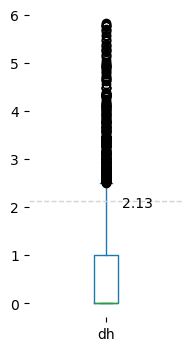

In [521]:
ax = VOCAB.dh.plot.box(figsize=(2,4))
vline = VOCAB.dh.quantile(.9).round(2)
ax.axhline(vline, ls='--', lw=1, c='lightgray')
ax.annotate(vline, xy=(1.1,2))
sns.despine(left=True, bottom=True)
plt.show()

In [522]:
dh_thresh = vline

sig_mask = VOCAB.dh > dh_thresh
SIGS = VOCAB[sig_mask].index
len(VOCAB), len(SIGS)

(4334, 432)

In [523]:
SIGS = VOCAB.sort_values('dh').tail(500).index

# CTM to TFIDF

In [524]:
TF = CTM[SIGS]
DF = TF[TF > 0].sum()
IDF = np.log((n_chunks+1)/(DF+1)+1)
TFIDF = TF * IDF
L2_norm = np.sqrt((TFIDF**2).sum(1))
TFIDF_L2 = TFIDF.div(L2_norm, axis=0)

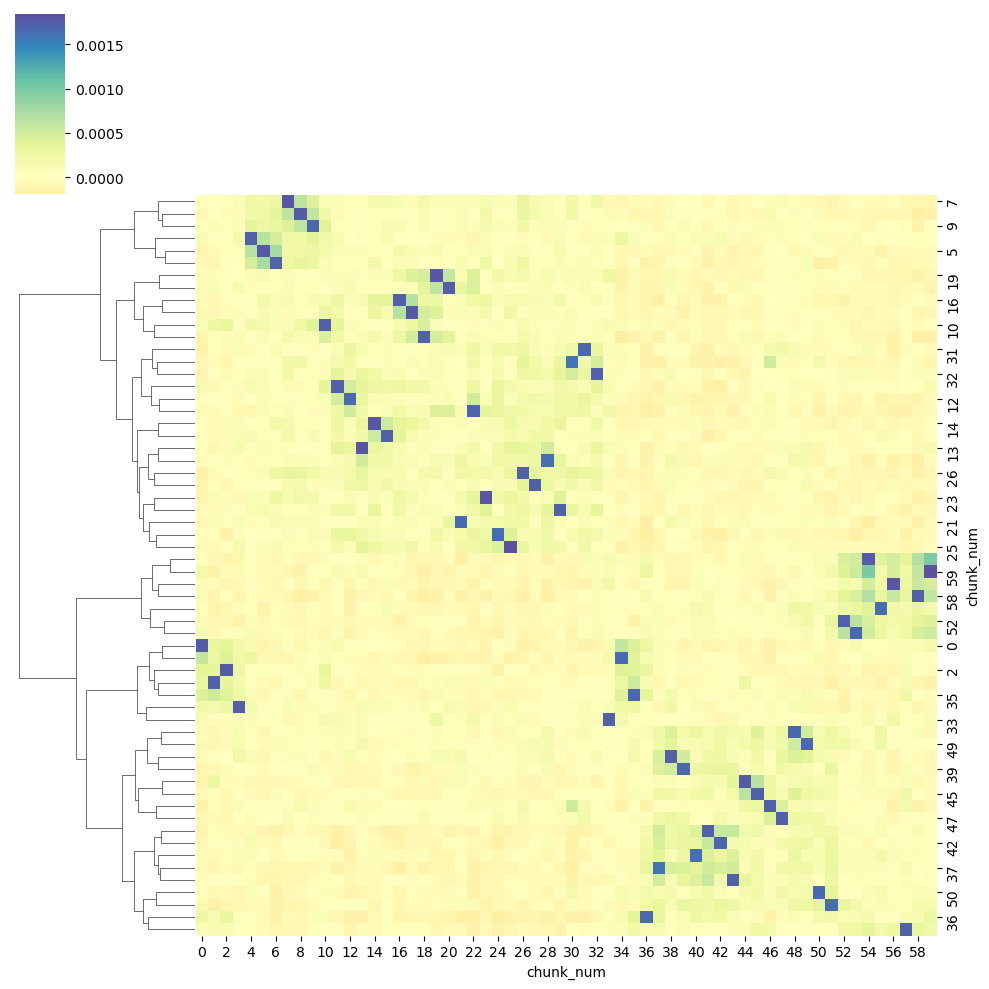

In [525]:
sns.clustermap(TFIDF_L2.T.cov(), cmap="Spectral", center=0, col_cluster=None, 
    metric='euclidean',
    method='ward')
plt.show()

# Save

In [526]:
TOKEN.to_csv(f"{src_id}-TOKEN.csv", index=True)
VOCAB.to_csv(f"{src_id}-VOCAB.csv", index=True)
DOC.to_csv(f"{src_id}-DOC.csv", index=True)
CHUNK.to_csv(f"{src_id}-CHUNK-{n_chunks}.csv", index=True)
TFIDF_L2.to_csv(f"{src_id}-TFIDF-{n_chunks}.csv", index=True)